In [12]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Análise do Conjunto de Dados: Cartas de Baralho

## Dipositivo 
#### Especificações
- Nome: Samsung Galaxy A33
- Camera - Megapixel: 48 Mp + 8 Mp + 5 Mp + 2 Mp 
- Resolução: 8000 x 6000 pixel

### Dataset

###  Classe 1: Copas (Hearts)

### 1. `2_hearth.jpg`
* **Condição de iluminação:** Luz artificial (ambiente interno, luz de teto/luminária).
* **Distância aproximada:** ~15 a 20 cm (Close-up, ângulo perpendicular).

### 2. `4_hearth.jpg`
* **Condição de iluminação:** Luz artificial direcional (ambiente interno).
* **Distância aproximada:** ~15 a 20 cm (Close-up, ângulo perpendicular).

### 3. `7_hearth.jpg`
* **Condição de iluminação:** Luz artificial (ambiente interno).
* **Distância aproximada:** ~15 a 20 cm (Close-up, ângulo perpendicular).

### 4. `8_hearth.jpg`
* **Condição de iluminação:** Luz artificial direta (ambiente interno, gerando sombras duras sobre a mão).
* **Distância aproximada:** ~15 cm (Segurada na mão).


### 5. `a_hearth.jpg`
* **Condição de iluminação:** Contraluz / Luz mista (fundo com luz natural forte de uma janela, objeto principal na sombra).
* **Distância aproximada:** ~15 a 20 cm (Segurada na mão, ângulo reto).



### Classe 2: Espadas (Spades)

### 6. `5_spade.jpg`
* **Condição de iluminação:** Luz natural difusa (ambiente claro, possivelmente luz de janela refletida no piso).
* **Distância aproximada:** ~40 a 50 cm (Distância média, ângulo superior inclinado).

### 7. `6_spade.jpg`
* **Condição de iluminação:** Luz artificial (ambiente interno, sobre mesa).
* **Distância aproximada:** ~15 a 20 cm (Close-up).

### 8. `a_spade.jpg`
* **Condição de iluminação:** Luz artificial (ambiente interno, luz provável de monitor ou abajur fraco).
* **Distância aproximada:** ~25 a 30 cm (Ângulo oblíquo/inclinado sobre a mesa).


### 9. `j_spade.jpg`
* **Condição de iluminação:** Luz natural difusa (ambiente claro, piso cerâmico).
* **Distância aproximada:** ~25 a 30 cm (Distância média-curta).

### 10. `k_spade.jpg`
* **Condição de iluminação:** Luz natural difusa (ambiente claro, piso cerâmico).
* **Distância aproximada:** ~25 a 30 cm (Distância média-curta).


## Caminho definido

In [13]:
heart = "../data/hearts/"
spade = "../data/spades/"

for name, path in {"hearts": heart, "spades": spade}.items():
    files = sorted(os.listdir(path))
    print(f"{name} ({len(files)}): {files}")    

hearts (5): ['2_hearth.jpeg', '4_hearth.jpeg', '7_hearth.jpeg', '8_hearth.jpeg', 'a_hearth.jpeg']
spades (5): ['5_spade.jpeg', '6_spade.jpeg', 'a_spade.jpeg', 'j_spade.jpeg', 'k_spade.jpeg']


### Transformações de Imagens

In [14]:
heart_sample = "../data/hearts/8_hearth.jpeg"
spade_sample = "../data/spades/a_spade.jpeg"
samples = {"hearts": heart_sample, "spades": spade_sample}

output_dir = "../data/transformed"
os.makedirs(output_dir, exist_ok=True)

###  Análise de Resolução
- 1 versão em resolução original (4000x3000)
- 1 versão com redução de 50% (2000x1500)
- 1 versão com redução de 20% (800x600)

**Observação:** A redução de resolução causa perda progressiva de detalhes finos (textura do papel, bordas dos símbolos). Em 20% da resolução original, símbolos como o naipe podem se tornar irreconhecíveis, impactando diretamente tarefas de classificação e detecção em visão computacional.

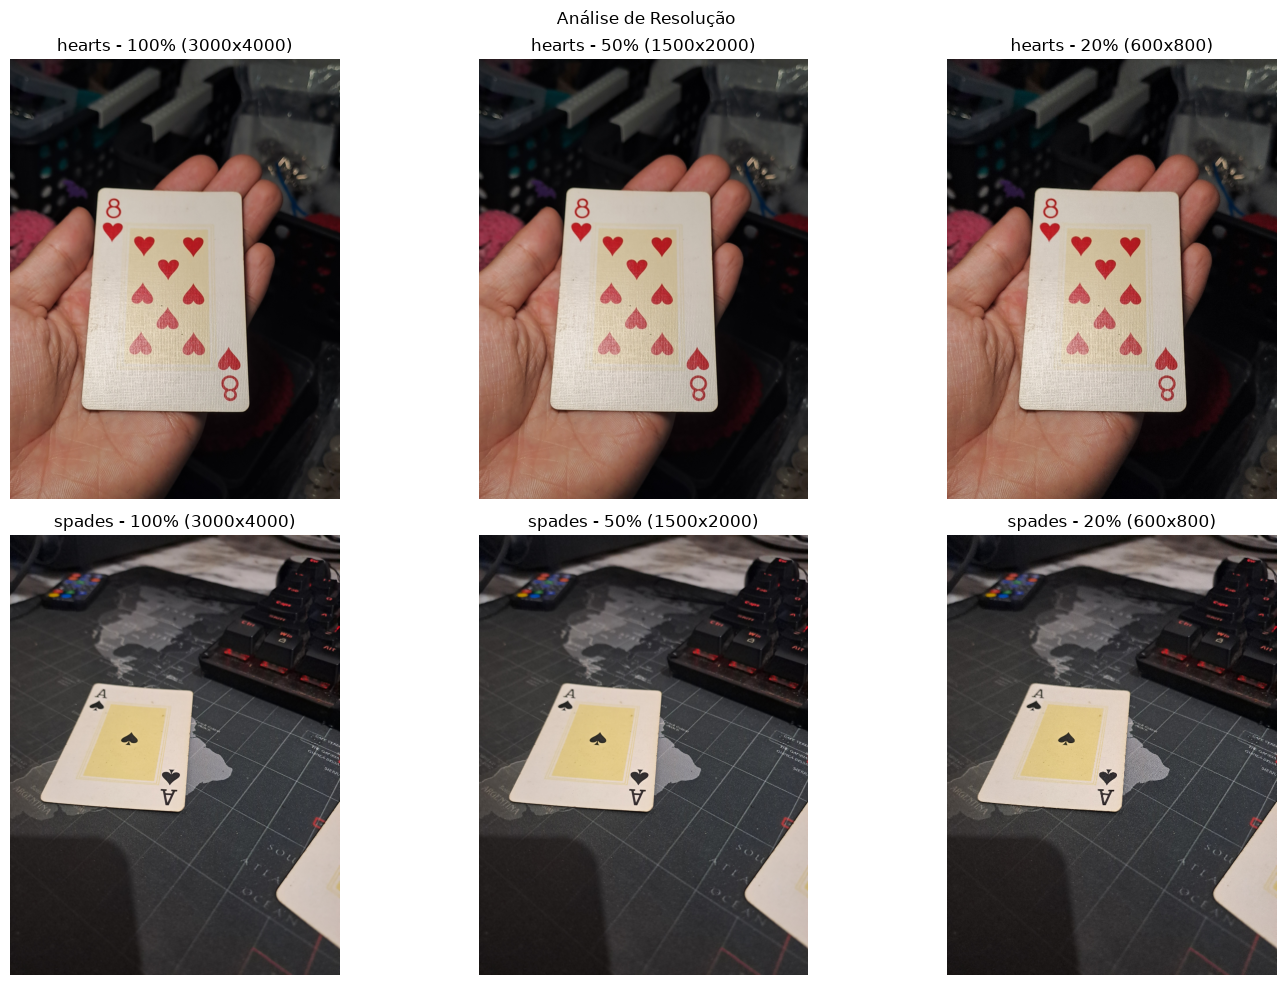

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for row, (name, path) in enumerate(samples.items()):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    for col, scale in enumerate([1.0, 0.5, 0.2]):
        resized = cv2.resize(img, (int(w*scale), int(h*scale)))
        axes[row][col].imshow(resized)
        axes[row][col].set_title(f"{name} - {int(scale*100)}% ({resized.shape[1]}x{resized.shape[0]})")
        axes[row][col].axis("off")
plt.suptitle(" Análise de Resolução")
plt.tight_layout()
plt.show()

### Espaço de Cor
Visualização em RGB, HSV e Escala de Cinza.

**Diferenças visuais:** RGB preserva todas as informações de cor; HSV separa matiz, saturação e brilho, facilitando segmentação por cor (ex: naipe vermelho vs preto); Escala de cinza elimina informação de cor, mantendo apenas luminância.

**Aplicações:** RGB para tarefas gerais de classificação; HSV para segmentação e detecção de objetos coloridos; Cinza para OCR e detecção de bordas.

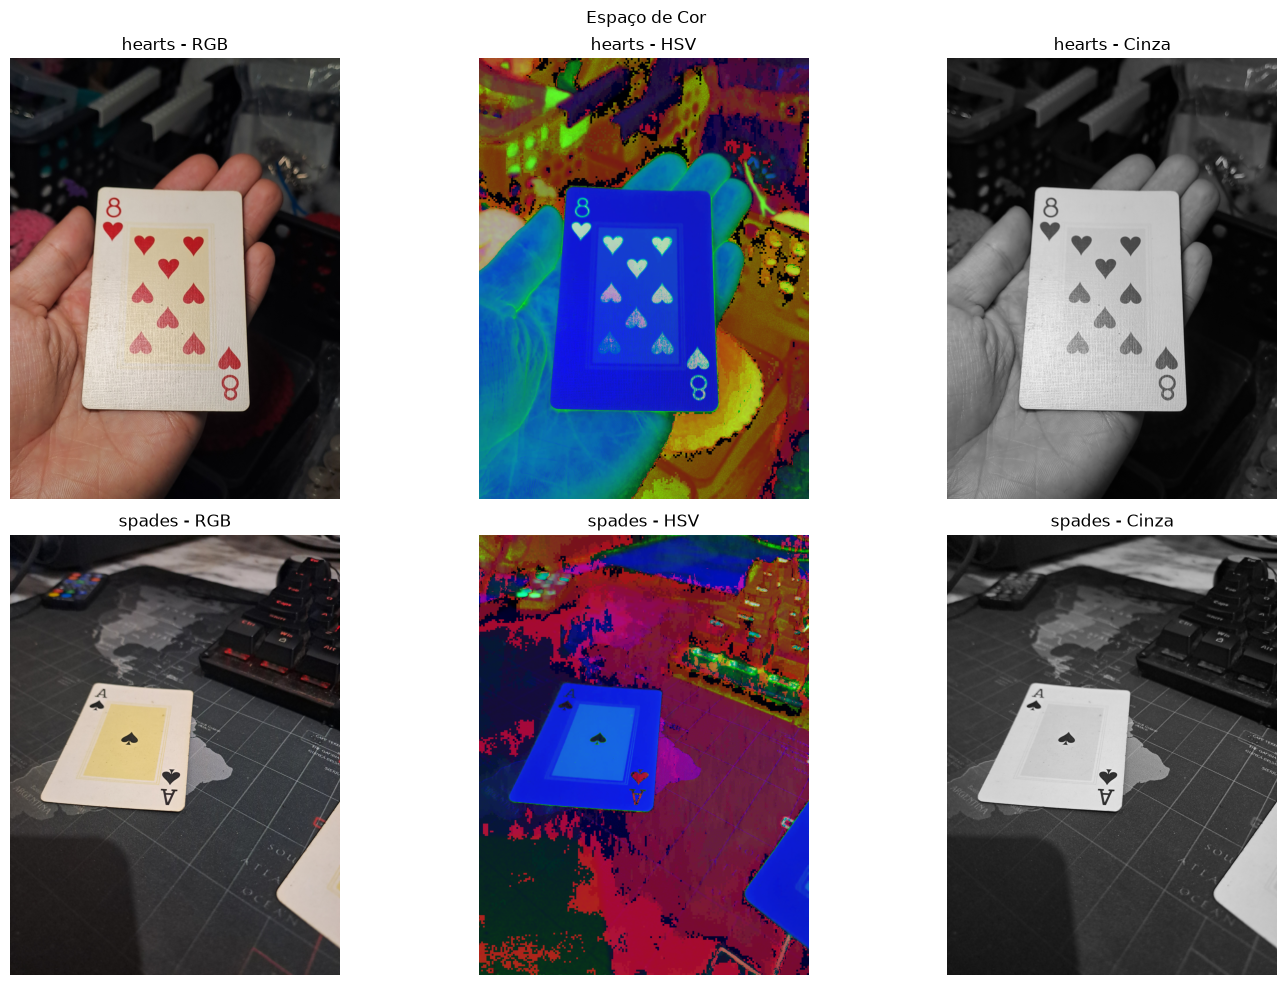

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for row, (name, path) in enumerate(samples.items()):
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    for col, (title, data, cmap) in enumerate([
        ("RGB", img_rgb, None),
        ("HSV", img_hsv, None),
        ("Cinza", img_gray, "gray")
    ]):
        axes[row][col].imshow(data, cmap=cmap)
        axes[row][col].set_title(f"{name} - {title}")
        axes[row][col].axis("off")
plt.suptitle(" Espaço de Cor")
plt.tight_layout()
plt.show()

### Quantização
Versões em 256, 64, 32 e 2 níveis de cinza.

**O que muda:** Com 256 níveis há transições suaves; com 64 e 32 surgem faixas visíveis (posterização); com 2 níveis (binarização) apenas contornos e regiões de alto contraste são preservados.

**Versão mais útil para o dataset:** 64 níveis — preserva detalhes suficientes dos naipes e números sem ruído excessivo. Para OCR de cartas, 32 níveis pode ser suficiente; para segmentação de fundo, 2 níveis é ideal.

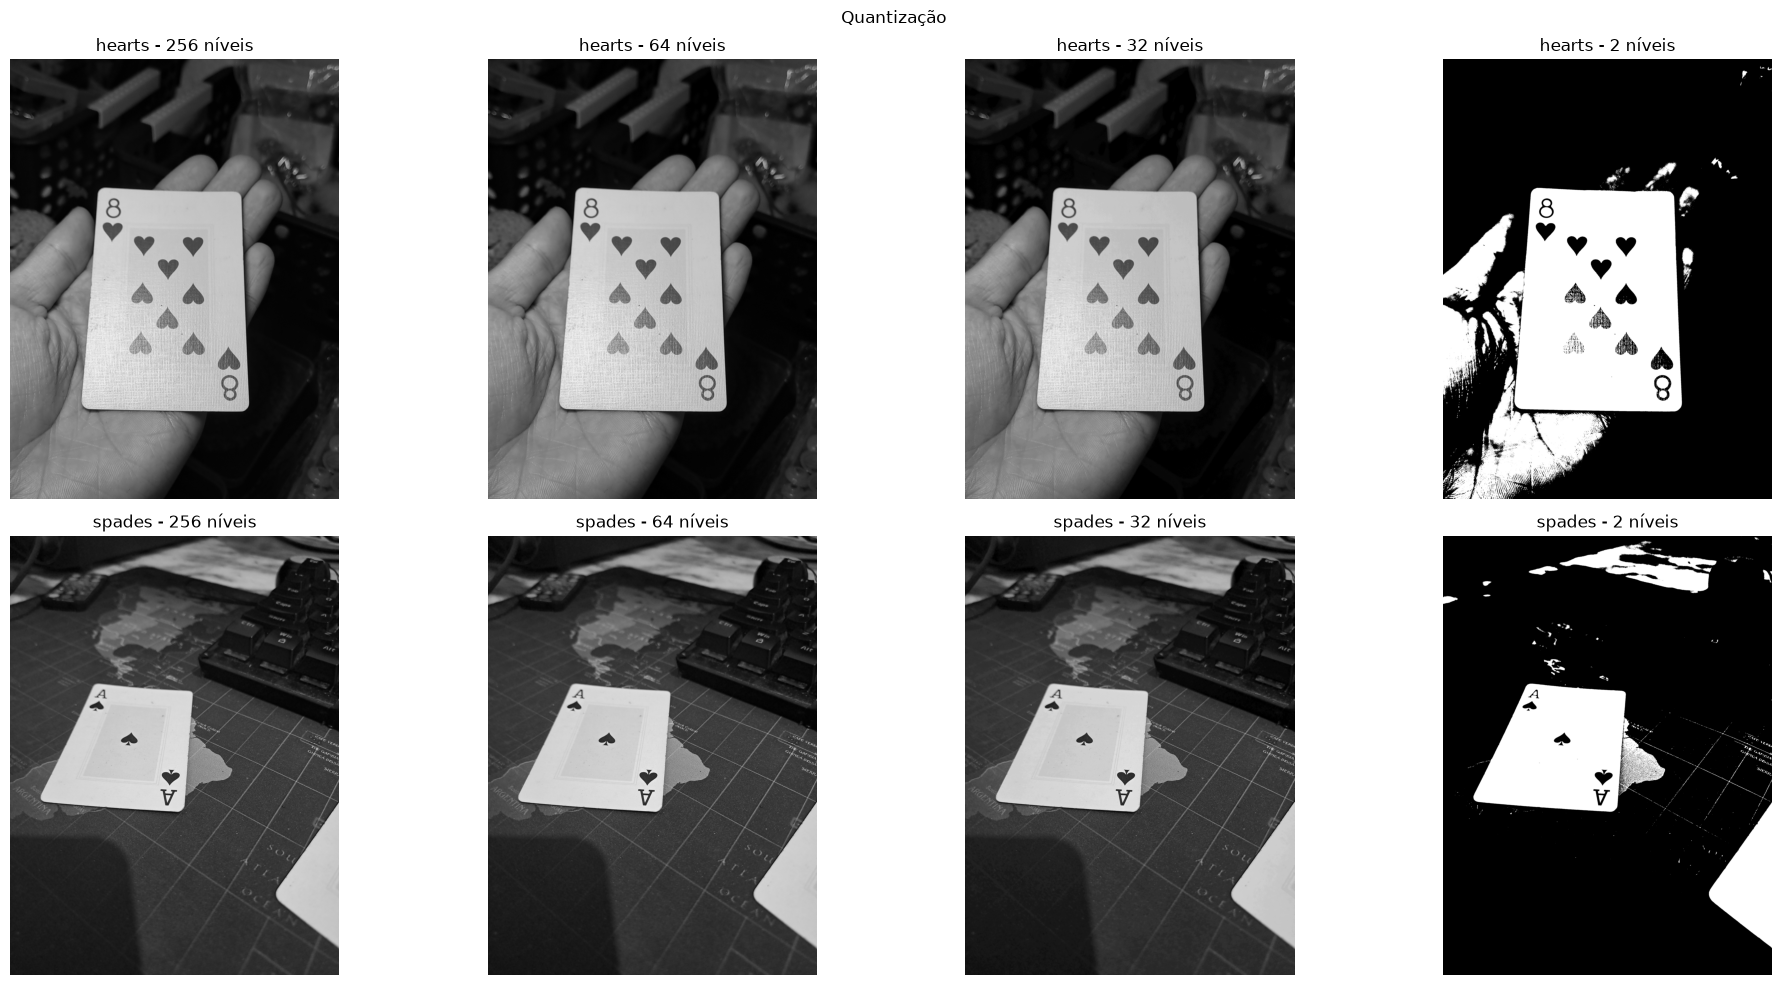

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for row, (name, path) in enumerate(samples.items()):
    img_gray = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2GRAY)
    for col, levels in enumerate([256, 64, 32, 2]):
        factor = 256 // levels
        quantized = (img_gray // factor) * factor
        axes[row][col].imshow(quantized, cmap="gray")
        axes[row][col].set_title(f"{name} - {levels} níveis")
        axes[row][col].axis("off")
plt.suptitle( " Quantização")
plt.tight_layout()
plt.show()

### Formato de Arquivo
Salvar em JPEG (com compressão) e PNG (sem perdas).

In [18]:
for name, path in samples.items():
    img = cv2.imread(path)
    jpeg_path = f"{output_dir}/{name}_compressed.jpg"
    png_path = f"{output_dir}/{name}_lossless.png"
    cv2.imwrite(jpeg_path, img, [cv2.IMWRITE_JPEG_QUALITY, 50])
    cv2.imwrite(png_path, img)
    jpeg_kb = os.path.getsize(jpeg_path) / 1024
    png_kb = os.path.getsize(png_path) / 1024
    print(f"{name}: JPEG={jpeg_kb:.1f} KB | PNG={png_kb:.1f} KB")

hearts: JPEG=475.3 KB | PNG=13750.1 KB
spades: JPEG=495.8 KB | PNG=14706.2 KB


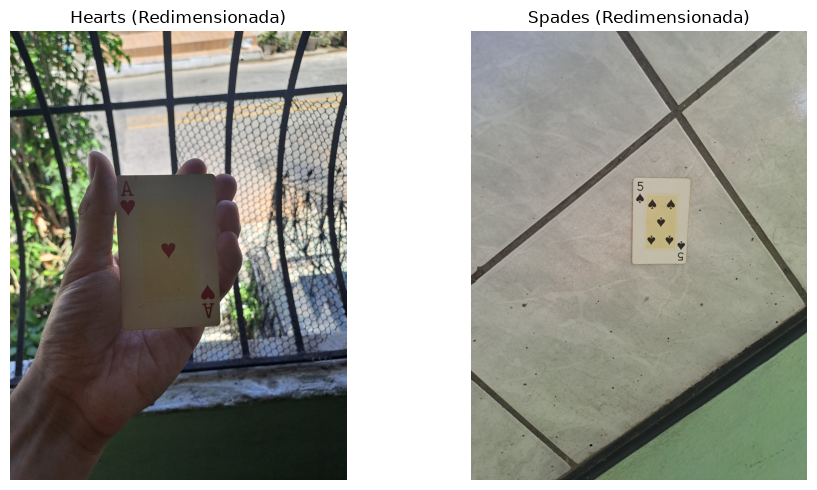

In [20]:
heart_path = "../data/hearts/a_hearth.jpeg" 
spade_path = "../data/spades/5_spade.jpeg" 

hearts = cv2.imread(heart_path)
spades = cv2.imread(spade_path)

if hearts is None or spades is None:
    print("Erro: Uma das imagens não foi encontrada. Verifique os caminhos e extensões.")
else:
    lowHearts = cv2.resize(hearts, None, fx=0.5, fy=0.5)
    lowSpades = cv2.resize(spades, None, fx=0.5, fy=0.5)

    lowHearts_rgb = cv2.cvtColor(lowHearts, cv2.COLOR_BGR2RGB)
    lowSpades_rgb = cv2.cvtColor(lowSpades, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(lowHearts_rgb)
    axes[0].set_title("Hearts (Redimensionada)")
    axes[0].axis('off')  # Oculta os eixos do gráfico

    axes[1].imshow(lowSpades_rgb)
    axes[1].set_title("Spades (Redimensionada)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()